<a href="https://colab.research.google.com/github/ayushmant908-web/machine_learning-100-Days/blob/main/Asumption_of_linear_regression_ml_day_50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('/content/drive/MyDrive/data.csv')

In [3]:
df.head()

,feature1,feature2,feature3,target
0,-0.570563,1.420342,0.495580,-9.763182
1,-0.990563,0.556965,1.045064,-24.029355
2,-0.674728,0.150617,1.774645,45.616421
3,0.388250,-0.387127,-0.110229,34.135737
4,1.167882,-0.024104,0.145063,86.663647


In [4]:
df.shape

(200, 4)

In [5]:
X=df.iloc[:,0:3].values
y=df.iloc[:,-1].values

In [6]:

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=1)

In [7]:
from sklearn.linear_model import LinearRegression

In [8]:
lr=LinearRegression()

In [9]:
lr.fit(X_train,y_train)

LinearRegression()

In [10]:
y_pred=lr.predict(X_test)

In [11]:
residual=y_test-y_pred

In [12]:
residual.shape,y_pred.shape

((60,), (60,))

# **Linear relationship\**

---



---



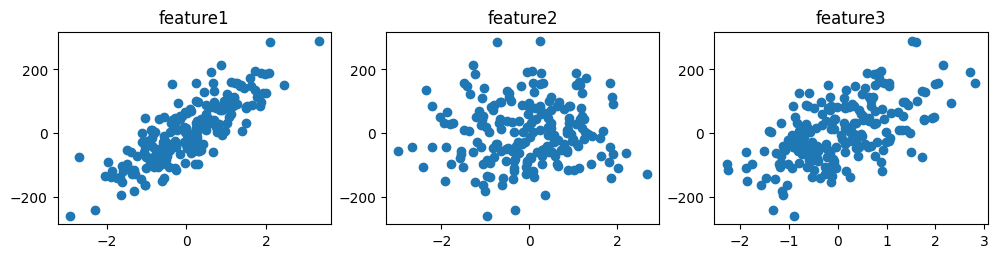

In [13]:
fig,(ax1,ax2,ax3)=plt.subplots(ncols=3,figsize=(12,2.5))
ax1.scatter(df['feature1'],df['target'])
ax1.set_title('feature1')
ax2.scatter(df['feature2'],df['target'])
ax2.set_title('feature2')
ax3.scatter(df['feature3'], df['target'])
ax3.set_title('feature3')
plt.show()

# **[multicolanrity](https://)**

In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif=[]
for i in range(X_train.shape[1]):
  vif.append(variance_inflation_factor(X_train,i))



In [15]:
pd.DataFrame({'vif':vif},index=df.columns[0:3]).T

,feature1,feature2,feature3
vif,1.01069,1.010174,1.014208


<Axes: >

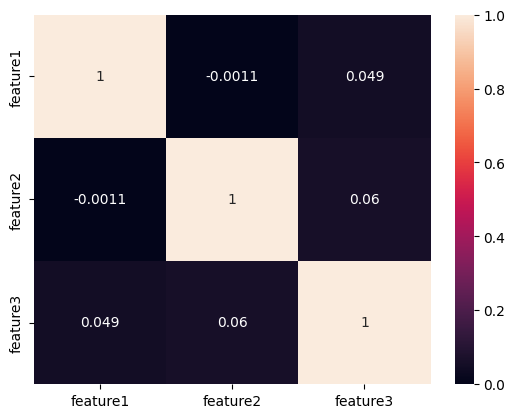

In [16]:
#another technique to find the multicolonarity
sns.heatmap(df.iloc[:,0:3].corr(),annot=True)

# **Normal_residual**






/tmp/ipykernel_659/2429947575.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residual,kde=True,hist=False)


<Axes: ylabel='Density'>

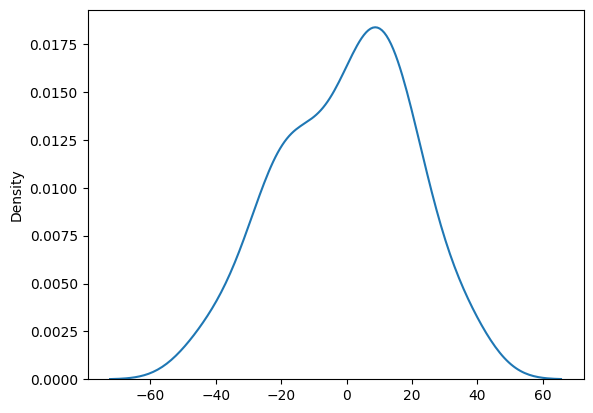

In [17]:
sns.distplot(residual,kde=True,hist=False)

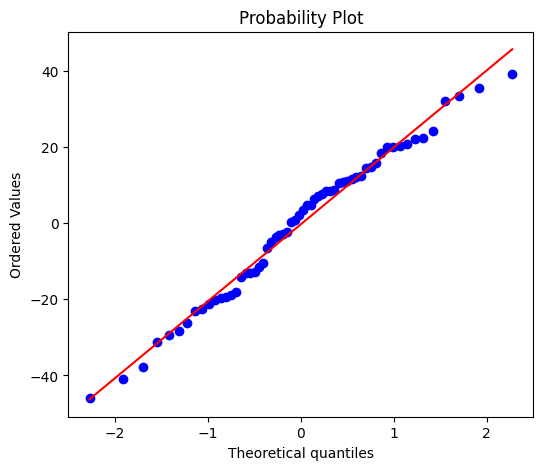

In [18]:
# QQ plot
import scipy as sp
fig,ax=plt.subplots(figsize=(6,5))
sp.stats.probplot(residual,plot=ax,fit=True)
plt.show()

# **[Homoscedasticity](https://)**

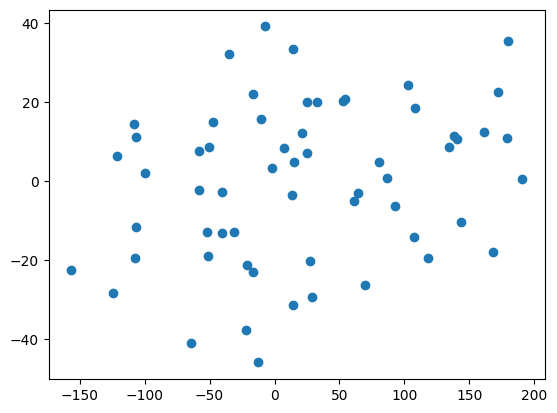

In [19]:
plt.scatter(y_pred,residual)

# **`Autocorelation of residual`**

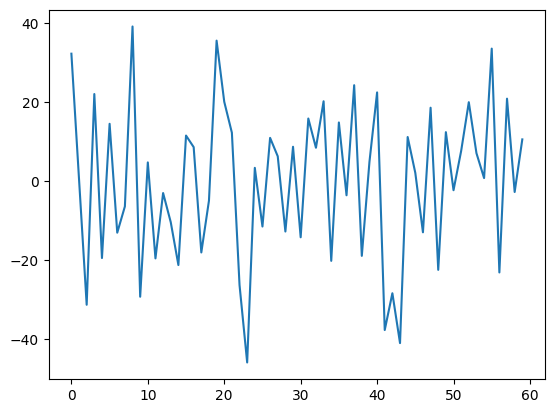

In [20]:
plt.plot(residual)